# ETAPE 2 — Nettoyage des données
**Projet : Optimisation du Réseau de Boutiques TELECOM — Groupe 5 SUD-EST**

---
> **RÈGLE D'OR** : Des données sales = des analyses fausses = des recommandations erronées.  
> Chaque décision de nettoyage est documentée dans `journal_nettoyage.txt`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Journal de nettoyage
journal = []
def log(msg):
    journal.append(msg)
    print(msg)

## 2.1 Chargement des données brutes

In [2]:
df_raw  = pd.read_csv('Fichier_Principal_pedago_anonym.csv', low_memory=False)
coord   = pd.read_csv('COORD_BQT.csv')
lib     = pd.read_csv('LIB_BQT.csv')

n_init = len(df_raw)
log(f"[INIT] Fichier principal brut : {n_init:,} lignes")
log(f"[INIT] COORD_BQT brut         : {len(coord)} lignes")
log(f"[INIT] LIB_BQT brut           : {len(lib)} lignes")

[INIT] Fichier principal brut : 3,258,114 lignes
[INIT] COORD_BQT brut         : 1042 lignes
[INIT] LIB_BQT brut           : 3435 lignes


## 2.2 Valeurs manquantes — Fichier principal

                       Nulls  % Nulls
PERSON_BIRTH_DT_year  176805     5.43
PERSON_SALUTATION_CD  149588     4.59
NET_ZONE_IN            48715     1.50
DENSE_ZONE_IN          48715     1.50
Geolife                 8406     0.26
CITY_LN                  472     0.01


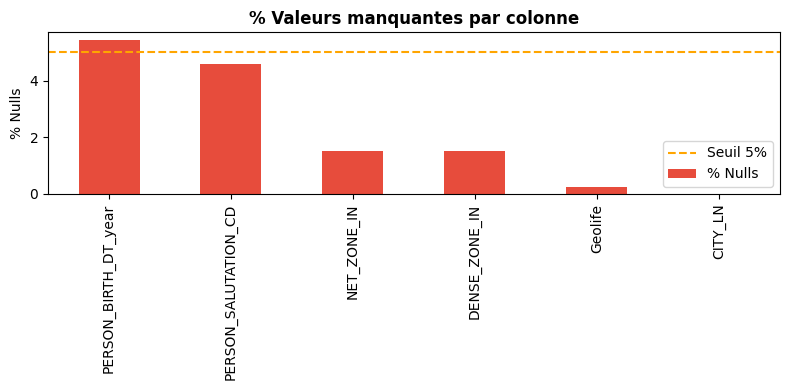

In [3]:
nulls = df_raw.isnull().sum()
nulls_pct = (nulls / len(df_raw) * 100).round(2)
null_df = pd.DataFrame({'Nulls': nulls, '% Nulls': nulls_pct})
null_df = null_df[null_df['Nulls'] > 0].sort_values('% Nulls', ascending=False)
print(null_df)

# Visualisation
if len(null_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    null_df['% Nulls'].plot(kind='bar', ax=ax, color='#e74c3c')
    ax.axhline(5, color='orange', linestyle='--', label='Seuil 5%')
    ax.set_title('% Valeurs manquantes par colonne', fontweight='bold')
    ax.set_ylabel('% Nulls')
    ax.legend()
    plt.tight_layout()
    plt.savefig('nulls_avant_nettoyage.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2.3 Filtre ZONE = 5_SUD_EST (prioritaire)

In [4]:
df = df_raw[df_raw['ZONE'] == '5_SUD_EST'].copy()
n_filtre = len(df)
log(f"[ZONE] Filtre 5_SUD_EST : {n_filtre:,} lignes conservées ({n_init - n_filtre:,} supprimées)")

[ZONE] Filtre 5_SUD_EST : 326,478 lignes conservées (2,931,636 supprimées)


## 2.4 Suppression des doublons

In [5]:
n_avant = len(df)
df = df.drop_duplicates()
n_doublons = n_avant - len(df)
log(f"[DOUBLONS] {n_doublons} lignes 100% identiques supprimées")

[DOUBLONS] 81107 lignes 100% identiques supprimées


## 2.5 Nettoyage ORDER_SHOP_CD (clé de jointure)

In [6]:
# Supprimer espaces, uniformiser casse
df['ORDER_SHOP_CD']   = df['ORDER_SHOP_CD'].str.strip().str.upper()
coord['ORDER_SHOP_CD'] = coord['ORDER_SHOP_CD'].str.strip().str.upper()
lib['ORDER_SHOP_CD']   = lib['ORDER_SHOP_CD'].str.strip().str.upper()

# Supprimer lignes sans clé
n_avant = len(df)
df = df.dropna(subset=['ORDER_SHOP_CD'])
log(f"[ORDER_SHOP_CD] {n_avant - len(df)} lignes sans code boutique supprimées")
log(f"[ORDER_SHOP_CD] Nettoyage espaces + casse appliqué sur les 3 tables")

[ORDER_SHOP_CD] 0 lignes sans code boutique supprimées
[ORDER_SHOP_CD] Nettoyage espaces + casse appliqué sur les 3 tables


## 2.6 Traitement de PERIOD (YYYY + MM)

In [7]:
# Les colonnes sont déjà séparées : PERIOD_YYYY et PERIOD_MM
# On crée une date complète pour les analyses temporelles
df['PERIOD'] = pd.to_datetime(
    df['PERIOD_YYYY'].astype(str) + '-' + df['PERIOD_MM'].astype(str).str.zfill(2) + '-01'
)

# Vérification
print("Plage temporelle :")
print(f"  Début : {df['PERIOD'].min()}")
print(f"  Fin   : {df['PERIOD'].max()}")
print(f"  Années : {sorted(df['PERIOD_YYYY'].unique())}")
log(f"[PERIOD] Colonne PERIOD créée (datetime) de {df['PERIOD'].min().date()} à {df['PERIOD'].max().date()}")

Plage temporelle :
  Début : 2021-10-01 00:00:00
  Fin   : 2022-12-01 00:00:00
  Années : [np.int64(2021), np.int64(2022)]
[PERIOD] Colonne PERIOD créée (datetime) de 2021-10-01 à 2022-12-01


## 2.7 Traitement de PERSON_BIRTH_DT_year (décennie)

In [8]:
print("Valeurs uniques de PERSON_BIRTH_DT_year :")
print(df['PERSON_BIRTH_DT_year'].value_counts().sort_index())

Valeurs uniques de PERSON_BIRTH_DT_year :
PERSON_BIRTH_DT_year
1900-1909     3321
1920-1929      374
1930-1939     5111
1940-1949    16027
1950-1959    26477
1960-1969    38393
1970-1979    43720
1980-1989    43004
1990-1999    34603
2000-2009     6304
9990-9999    15281
Name: count, dtype: int64


In [9]:
# Extraire le début de la décennie (ex: '1970-1979' -> 1970)
def parse_birth_decade(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if '-' in val:
        try:
            return int(val.split('-')[0])
        except:
            return np.nan
    try:
        return int(val)
    except:
        return np.nan

df['birth_decade'] = df['PERSON_BIRTH_DT_year'].apply(parse_birth_decade)

# Valeurs aberrantes
n_avant = len(df)
df = df[df['birth_decade'].isna() | ((df['birth_decade'] >= 1920) & (df['birth_decade'] <= 2010))]
log(f"[BIRTH] {n_avant - len(df)} lignes supprimées (décennie hors plage 1920-2010)")

# Age approximatif (milieu de décennie)
ANNEE_REF = 2024
df['age_client'] = ANNEE_REF - (df['birth_decade'] + 5)  # milieu de la décennie
print(f"\nAge moyen clients SUD-EST : {df['age_client'].mean():.1f} ans")
print(f"Age min/max : {df['age_client'].min():.0f} / {df['age_client'].max():.0f} ans")

[BIRTH] 18602 lignes supprimées (décennie hors plage 1920-2010)

Age moyen clients SUD-EST : 50.4 ans
Age min/max : 19 / 99 ans


## 2.8 Nettoyage CITY_LN

In [10]:
# Normalisation casse + strip
df['CITY_LN'] = df['CITY_LN'].str.strip().str.upper()

n_avant = len(df)
df = df.dropna(subset=['CITY_LN'])
log(f"[CITY_LN] {n_avant - len(df)} lignes sans ville supprimées")
log(f"[CITY_LN] Normalisation casse appliquée")

print(f"\nTop 10 villes clients SUD-EST :")
print(df['CITY_LN'].value_counts().head(10))

[CITY_LN] 92 lignes sans ville supprimées
[CITY_LN] Normalisation casse appliquée

Top 10 villes clients SUD-EST :
CITY_LN
NICE               10494
MARSEILLE           5712
AIX EN PROVENCE     4298
TOULON              4096
ANTIBES             3108
CANNES              2696
AJACCIO             2655
FREJUS              2028
AVIGNON             2025
BASTIA              1714
Name: count, dtype: int64


## 2.9 Nettoyage Geolife

In [11]:
print("Catégories Geolife :")
print(df['Geolife'].value_counts().head(15))
print(f"\nNulls Geolife : {df['Geolife'].isnull().sum()}")

# Imputer les nulls par 'Non renseigné'
n_nulls_geo = df['Geolife'].isnull().sum()
df['Geolife'] = df['Geolife'].fillna('Non renseigné')
log(f"[GEOLIFE] {n_nulls_geo} nulls imputés par 'Non renseigné'")

Catégories Geolife :
Geolife
03D_sedentaire             21304
11B_mixte                  20918
07B_actif                  17024
06A_quartier recent        14356
06C_residentiel            12043
08C_famille active         10919
11A_saisonnier             10504
02C_mix pavillon           10449
03C_intermediaire           9861
04A_coeur historique        9488
07C_senior                  9069
08A_rurbanisation           7859
04C_social                  7757
02B_quartier historique     6832
04B_mix social              6586
Name: count, dtype: int64

Nulls Geolife : 0
[GEOLIFE] 0 nulls imputés par 'Non renseigné'


## 2.10 Nettoyage COORD_BQT

In [12]:
# Doublons
n_dup = coord.duplicated(subset='ORDER_SHOP_CD').sum()
coord = coord.drop_duplicates(subset='ORDER_SHOP_CD')
log(f"[COORD] {n_dup} boutiques en doublon supprimées")

# Nulls coordonnées
n_nulls_coord = coord[['Coord_L2E_II_X', 'Coord_L2E_II_Y']].isnull().any(axis=1).sum()
coord = coord.dropna(subset=['Coord_L2E_II_X', 'Coord_L2E_II_Y'])
log(f"[COORD] {n_nulls_coord} boutiques sans coordonnées supprimées")

# Normaliser emplacement
coord['Emplacement_PDV'] = coord['Emplacement_PDV'].str.strip().str.upper()
print("Emplacement boutiques :")
print(coord['Emplacement_PDV'].value_counts())

[COORD] 0 boutiques en doublon supprimées
[COORD] 84 boutiques sans coordonnées supprimées
Emplacement boutiques :
Emplacement_PDV
CV               500
CC               457
HORS CV ET CC      1
Name: count, dtype: int64


## 2.11 Nettoyage LIB_BQT

In [13]:
n_dup_lib = lib.duplicated(subset='ORDER_SHOP_CD').sum()
lib = lib.drop_duplicates(subset='ORDER_SHOP_CD')
lib['MKT_CHANNL_LB'] = lib['MKT_CHANNL_LB'].str.strip()
log(f"[LIB] {n_dup_lib} doublons supprimés")
print("Canaux marketing :")
print(lib['MKT_CHANNL_LB'].value_counts())

[LIB] 0 doublons supprimés
Canaux marketing :
MKT_CHANNL_LB
Réseau Concurrentiel               909
Agence Distribution                744
Réseau Partenaire                  626
Service Client Home                567
Ag PRO/PME                         171
Service Client Mobile              122
Direction des ventes indirectes    119
Indéterminé                         73
Back Office Autre                   38
On Line                             20
Porte A Porte                       16
Proactif Home                       13
Grands Comptes                       8
Clic To Call                         5
Opérations Spéciales                 4
Name: count, dtype: int64


## 2.12 Bilan final du nettoyage

In [14]:
print("=" * 55)
print("BILAN NETTOYAGE — FICHIER PRINCIPAL SUD-EST")
print("=" * 55)
print(f"Lignes initiales (national)  : {n_init:>10,}")
print(f"Lignes après filtre SUD-EST  : {n_filtre:>10,}")
print(f"Lignes après nettoyage final : {len(df):>10,}")
print(f"Perte nettoyage              : {n_filtre - len(df):>10,} ({(n_filtre - len(df))/n_filtre*100:.2f}%)")
print("=" * 55)

BILAN NETTOYAGE — FICHIER PRINCIPAL SUD-EST
Lignes initiales (national)  :  3,258,114
Lignes après filtre SUD-EST  :    326,478
Lignes après nettoyage final :    226,677
Perte nettoyage              :     99,801 (30.57%)


In [15]:
# Sauvegarder le journal
with open('journal_nettoyage.txt', 'w', encoding='utf-8') as f:
    f.write("JOURNAL DE NETTOYAGE — Projet TELECOM Groupe 5 SUD-EST\n")
    f.write("=" * 60 + "\n")
    for entry in journal:
        f.write(entry + "\n")
print("Journal sauvegardé dans journal_nettoyage.txt")

# Sauvegarder les données nettoyées intermédiaires
df.to_csv('df_sud_est_propre.csv', index=False)
coord.to_csv('coord_propre.csv', index=False)
lib.to_csv('lib_propre.csv', index=False)
print("Fichiers nettoyés sauvegardés.")

Journal sauvegardé dans journal_nettoyage.txt
Fichiers nettoyés sauvegardés.


## Conclusion Etape 2

| Vérification | Résultat |
|---|---|
| Filtre ZONE 5_SUD_EST | Appliqué |
| Doublons | Supprimés |
| ORDER_SHOP_CD | Nettoyé (strip + upper) |
| PERIOD | Colonne datetime créée |
| PERSON_BIRTH_DT_year | Décennie extraite, aberrants supprimés |
| CITY_LN | Normalisé (upper + strip) |
| Geolife | Nulls imputés |
| Coordonnées | Vérifiées et nettoyées |

**→ Prochaine étape : Jointure des tables (Etape 3)**